# Giai đoạn 1: Xử lý dữ liệu (Data Preprocessing)


**Dự án:** Phát hiện gian lận thẻ tín dụng (Credit Card Fraud Detection)

**Notebook này thực hiện các công việc:**
1. Tải dữ liệu
2. Làm sạch và xử lý giá trị thiếu
3. Chuẩn hóa dữ liệu (Scaling)
4. Chia tập dữ liệu Train/Test
5. Áp dụng các kỹ thuật cân bằng dữ liệu: SMOTE, ADASYN, Random Undersampling, Class Weights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

warnings.filterwarnings('ignore')


## 1. Tải và Khám phá bộ dữ liệu

**Lưu ý:** Tập dữ liệu creditcard.csv được tải từ file CSV và khám phá các đặc trưng cơ bản.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Phân phối nhãn (0: Bình thường, 1: Gian lận):
Class
0    284315
1       492
Name: count, dtype: int64


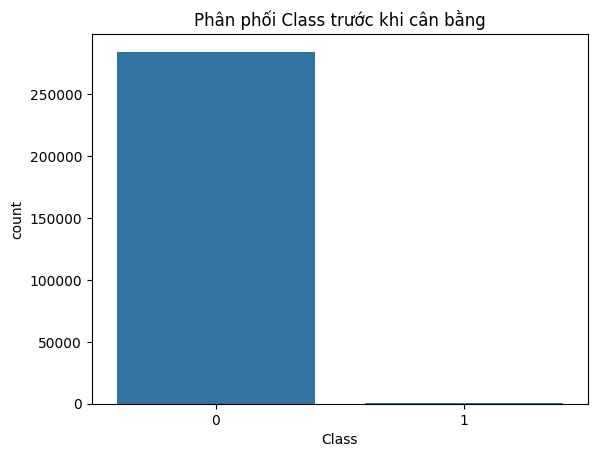

In [2]:
df = pd.read_csv('creditcard.csv')

display(df.head())

print('Phân phối nhãn (0: Bình thường, 1: Gian lận):')
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title('Phân phối Class trước khi cân bằng')
plt.show()


## 2. Làm sạch dữ liệu và Xử lý giá trị thiếu

Kiểm tra và xử lý các giá trị thiếu (missing values) và dữ liệu trùng lặp.


In [3]:
missing_values = df.isnull().sum().max()
print(f'Số lượng giá trị thiếu lớn nhất trong các cột: {missing_values}')

if missing_values > 0:
    df.dropna(inplace=True)
    print('Đã loại bỏ các dòng có chứa giá trị thiếu.')
else:
    print('Không có giá trị thiếu trong bộ dữ liệu.')

duplicates = df.duplicated().sum()
print(f'Số dòng trùng lặp: {duplicates}')
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print('Đã loại bỏ các dòng trùng lặp.')


Số lượng giá trị thiếu lớn nhất trong các cột: 0
Không có giá trị thiếu trong bộ dữ liệu.
Số dòng trùng lặp: 1081
Đã loại bỏ các dòng trùng lặp.


## 3. Chuẩn hóa đặc trưng (Scaling)

Các đặc trưng V1-V28 đã được xử lý bằng PCA. Tuy nhiên, Time và Amount cần được chuẩn hóa bằng RobustScaler để giảm tác động của các ngoại lệ (outliers).


In [4]:
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

display(df.head())


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## 4. Chia tập dữ liệu Train / Test

**Lưu ý quan trọng:** Việc chia tập dữ liệu phải diễn ra trước khi cân bằng dữ liệu (SMOTE/ADASYN). Nếu làm ngược lại sẽ gây ra hiện tượng rò rỉ dữ liệu (Data Leakage).


In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Kích thước tập Train:', X_train.shape)
print('Kích thước tập Test:', X_test.shape)
print('Phân phối nhãn tập Train:\n', y_train.value_counts())


Kích thước tập Train: (226980, 30)
Kích thước tập Test: (56746, 30)
Phân phối nhãn tập Train:
 Class
0    226602
1       378
Name: count, dtype: int64


## 5. Áp dụng kỹ thuật cân bằng dữ liệu

Tạo bốn phiên bản tập Train khác nhau tương ứng với các kỹ thuật cân bằng dữ liệu khác nhau để so sánh hiệu quả.


### 5.1. Undersampling

Giảm ngẫu nhiên số lượng mẫu bình thường để cân bằng với số lượng mẫu gian lận.


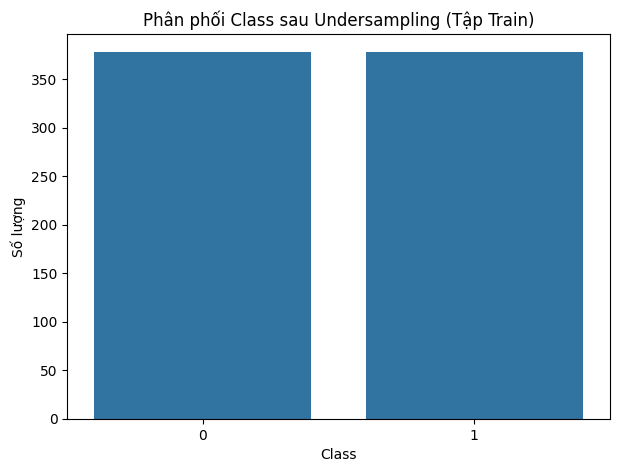

Phân phối nhãn sau Undersampling: Counter({0: 378, 1: 378})


In [6]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

plt.figure(figsize=(7, 5))
sns.countplot(x=y_train_under)
plt.title('Phân phối Class sau Undersampling (Tập Train)')
plt.xlabel('Class')
plt.ylabel('Số lượng')
plt.show()

print('Phân phối nhãn sau Undersampling:', Counter(y_train_under))


### 5.2. SMOTE

Tạo ra các mẫu gian lận giả dựa trên các mẫu thiểu số hiện có.


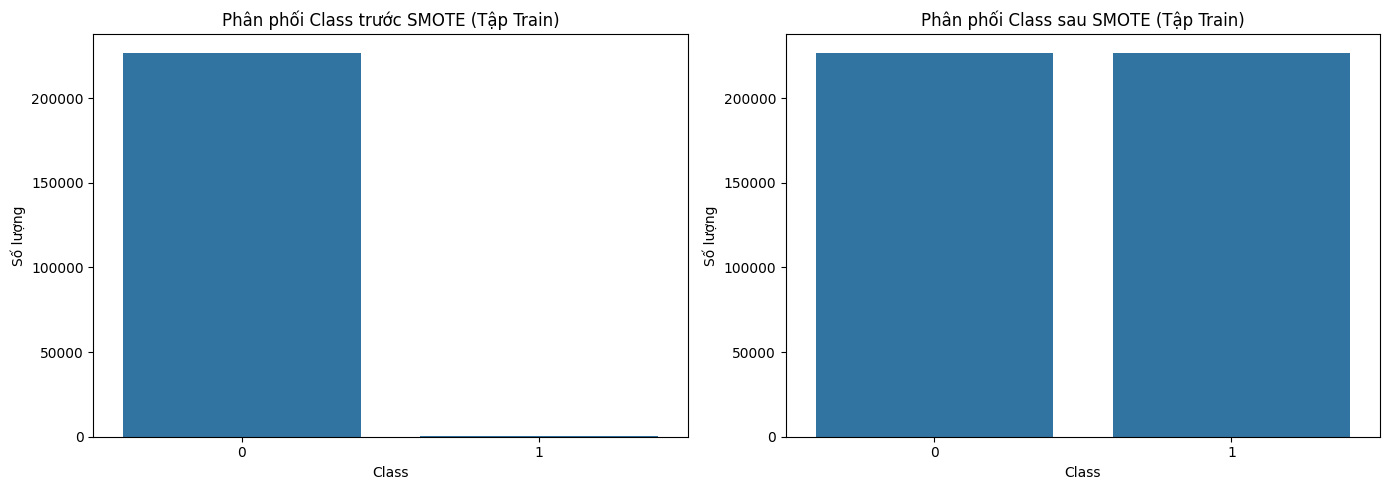

Phân phối nhãn trước SMOTE: Counter({0: 226602, 1: 378})
Phân phối nhãn sau SMOTE: Counter({0: 226602, 1: 226602})


In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Phân phối Class trước SMOTE (Tập Train)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Số lượng')

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title('Phân phối Class sau SMOTE (Tập Train)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

print('Phân phối nhãn trước SMOTE:', Counter(y_train))
print('Phân phối nhãn sau SMOTE:', Counter(y_train_smote))


### 5.3. ADASYN

Kỹ thuật lấy mẫu quá mức thích ứng (Adaptive Synthetic Sampling).


In [8]:
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
print('Phân phối nhãn sau ADASYN:', Counter(y_train_adasyn))


Phân phối nhãn sau ADASYN: Counter({0: 226602, 1: 226567})


### 5.4. Class Weights

Phương pháp gán trọng số khác nhau cho mỗi lớp trong quá trình huấn luyện.


In [9]:
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print("Class weights:", weights)


Class weights: [  0.50083406 300.23809524]


## 6. Lưu dữ liệu đã xử lý

Lưu các tập dữ liệu đã xử lý để sử dụng trong giai đoạn tiếp theo.


In [10]:
import pickle

with open('train_smote.pkl', 'wb') as f:
    pickle.dump((X_train_smote, y_train_smote), f)

with open('test_data.pkl', 'wb') as f:
    pickle.dump((X_test, y_test), f)

print('Hoàn tất Giai đoạn 1: Tiền xử lý dữ liệu!')

!pip install catboost lightgbm shap -q


Hoàn tất Giai đoạn 1: Tiền xử lý dữ liệu!


# Giai đoạn 2: Xây dựng và Huấn luyện Mô hình


Giai đoạn này tập trung vào xây dựng và huấn luyện các mô hình máy học khác nhau với các tập dữ liệu được cân bằng bằng các kỹ thuật khác nhau từ giai đoạn 1. Với mỗi kỹ thuật cân bằng, ta huấn luyện các mô hình khác nhau để so sánh hiệu suất.


In [11]:
import pickle
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

with open('train_smote.pkl', 'rb') as f:
    X_train_smote_loaded, y_train_smote_loaded = pickle.load(f)

print("Đang huấn luyện các mô hình đa dạng...")

xgb_smote = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_smote.fit(X_train_smote_loaded, y_train_smote_loaded)

et_smote = ExtraTreesClassifier(n_estimators=100, random_state=42)
et_smote.fit(X_train_smote_loaded, y_train_smote_loaded)

lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
lgbm_model.fit(X_train_smote_loaded, y_train_smote_loaded)

cat_model = CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0, random_state=42)
cat_model.fit(X_train_smote_loaded, y_train_smote_loaded)

xgb_under = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_under.fit(X_train_under, y_train_under)

xgb_adasyn = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_adasyn.fit(X_train_adasyn, y_train_adasyn)

xgb_weight_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, scale_pos_weight=weights[1], random_state=42)
xgb_weight_model.fit(X_train, y_train)

models = {
    "XGBoost_SMOTE": xgb_smote,
    "ExtraTrees_SMOTE": et_smote,
    "LightGBM_SMOTE": lgbm_model,
    "CatBoost_SMOTE": cat_model,
    "Undersampling-XGBoost": xgb_under,
    "ADASYN-XGBoost": xgb_adasyn,
    "XGBoost_ClassWeight": xgb_weight_model
}

with open('trained_models_smote.pkl', 'wb') as f:
    pickle.dump(models, f)

print("Đã huấn luyện xong 7 kịch bản và lưu vào trained_models_smote.pkl")


Đang huấn luyện các mô hình đa dạng...
Đã huấn luyện xong 7 kịch bản và lưu vào trained_models_smote.pkl


# Giai đoạn 3: Đánh Giá Mô hình


Đánh giá hiệu suất của các mô hình trên tập kiểm tra bằng các chỉ số: Precision, Recall, F1-Score, ROC-AUC và PR-AUC.


In [12]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("ĐANG ĐÁNH GIÁ MÔ HÌNH...\n")

with open('test_data.pkl', 'rb') as f:
    X_test, y_test = pickle.load(f)

with open('trained_models_smote.pkl', 'rb') as f:
    models = pickle.load(f)

with open('Bang_Diem_AI.txt', 'w', encoding='utf-8') as f_out:

    for name, model in models.items():

        print(f"\n===== {name} =====")

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)

        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("ROC-AUC:", roc_auc)
        print("PR-AUC:", pr_auc)

        f_out.write(f"\n===== {name} =====\n")
        f_out.write(f"Precision: {precision:.4f}\n")
        f_out.write(f"Recall: {recall:.4f}\n")
        f_out.write(f"F1 Score: {f1:.4f}\n")
        f_out.write(f"ROC-AUC: {roc_auc:.4f}\n")
        f_out.write(f"PR-AUC: {pr_auc:.4f}\n\n")

        f_out.write(classification_report(y_test, y_pred))
        f_out.write("\n" + "="*60 + "\n")

        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {name}')
        plt.savefig(f'Confusion_Matrix_{name}.png')
        plt.close()

print("\nHOÀN THÀNH ĐÁNH GIÁ")


ĐANG ĐÁNH GIÁ MÔ HÌNH...


===== XGBoost_SMOTE =====
Precision: 0.273972602739726
Recall: 0.8421052631578947
F1 Score: 0.4134366925064599
ROC-AUC: 0.9726368002051341
PR-AUC: 0.7935994416115169

===== ExtraTrees_SMOTE =====
Precision: 0.935064935064935
Recall: 0.7578947368421053
F1 Score: 0.8372093023255814
ROC-AUC: 0.9641005082829401
PR-AUC: 0.8234776267392723

===== LightGBM_SMOTE =====
Precision: 0.5661764705882353
Recall: 0.8105263157894737
F1 Score: 0.6666666666666666
ROC-AUC: 0.959937809431524
PR-AUC: 0.814006996446595

===== CatBoost_SMOTE =====
Precision: 0.3696682464454976
Recall: 0.8210526315789474
F1 Score: 0.5098039215686274
ROC-AUC: 0.9662833099058037
PR-AUC: 0.7565648627013244

===== Undersampling-XGBoost =====
Precision: 0.04978749241044323
Recall: 0.8631578947368421
F1 Score: 0.09414466130884042
ROC-AUC: 0.979590084812922
PR-AUC: 0.699736442570131

===== ADASYN-XGBoost =====
Precision: 0.15384615384615385
Recall: 0.8421052631578947
F1 Score: 0.2601626016260163
ROC-AUC: 0

# Giai đoạn 4: Giải Thích Mô hình


Sử dụng phương pháp SHAP (SHapley Additive exPlanations) để giải thích các quyết định của mô hình tốt nhất.


## 4.1. Khởi tạo SHAP và xác định mô hình tốt nhất


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
import shap

print("--- KHỞI TẠO SHAP & TÌM MÔ HÌNH TỐT NHẤT ---")

with open('test_data.pkl', 'rb') as f:
    X_test, y_test = pickle.load(f)

with open('trained_models_smote.pkl', 'rb') as f:
    models = pickle.load(f)

best_model_name = None
best_model_obj = None
best_pr_auc = -1

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_prob)
    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_model_name = name
        best_model_obj = model

print(f"Mô hình xuất sắc nhất được chọn: {best_model_name} (PR-AUC = {best_pr_auc:.4f})")

X_exai_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(best_model_obj)
shap_values_raw = explainer.shap_values(X_exai_sample)

if isinstance(shap_values_raw, list):
    final_shap_values = shap_values_raw[1] if len(shap_values_raw) > 1 else shap_values_raw[0]
elif len(shap_values_raw.shape) == 3:
    final_shap_values = shap_values_raw[:, :, 1]
else:
    final_shap_values = shap_values_raw

print("Đã tính toán xong giá trị SHAP.")


--- KHỞI TẠO SHAP & TÌM MÔ HÌNH TỐT NHẤT ---
Mô hình xuất sắc nhất được chọn: ExtraTrees_SMOTE (PR-AUC = 0.8235)
Đã tính toán xong giá trị SHAP.


## 4.2. Biểu đồ Feature Importance

Hiển thị mức độ quan trọng của các đặc trưng trong quyết định của mô hình bằng biểu đồ bar.


Vẽ biểu đồ Feature Importance cho mô hình: ExtraTrees_SMOTE


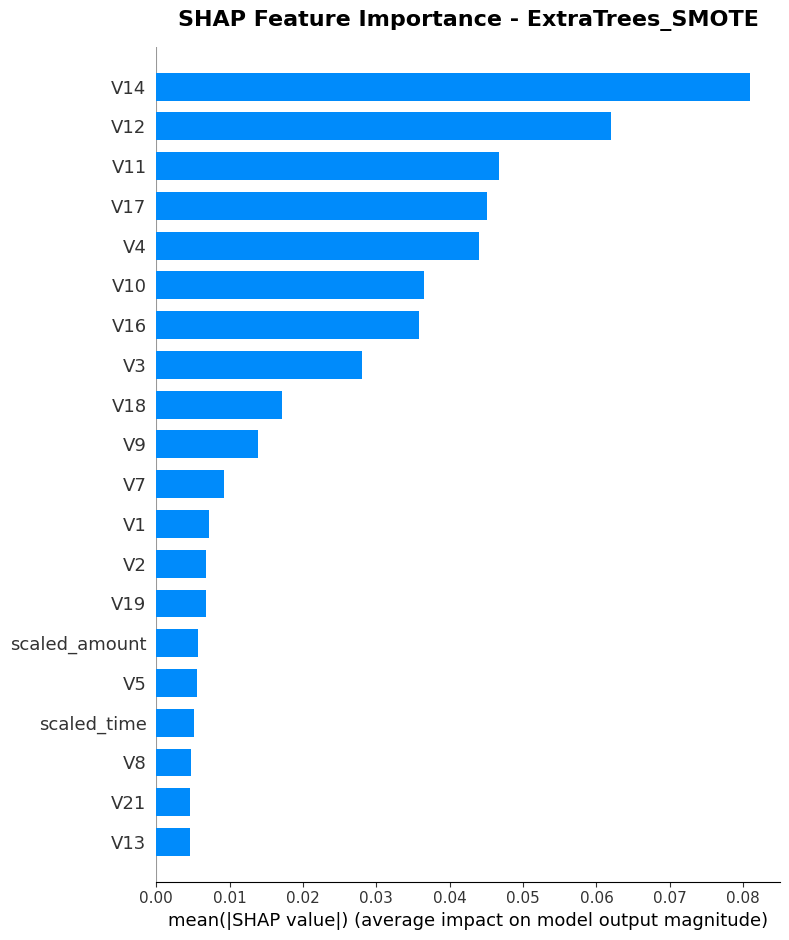

In [14]:
print(f"Vẽ biểu đồ Feature Importance cho mô hình: {best_model_name}")

plt.figure(figsize=(10, 5))
plt.title(f"SHAP Feature Importance - {best_model_name}", fontsize=16, fontweight='bold', pad=15)

shap.summary_plot(final_shap_values, X_exai_sample, plot_type="bar", show=False)

plt.tight_layout()
plt.savefig(f'SHAP_Feature_Importance_{best_model_name}.png', dpi=300)
plt.show()
plt.close()


## 4.3. Biểu đồ Summary Plot (Phân bổ và Xu hướng tác động)

Hiển thị phân bổ giá trị SHAP cho từng đặc trưng, cho phép xem xu hướng và phạm vi tác động của từng biến.


Vẽ biểu đồ Summary Plot (Beeswarm) cho mô hình: ExtraTrees_SMOTE


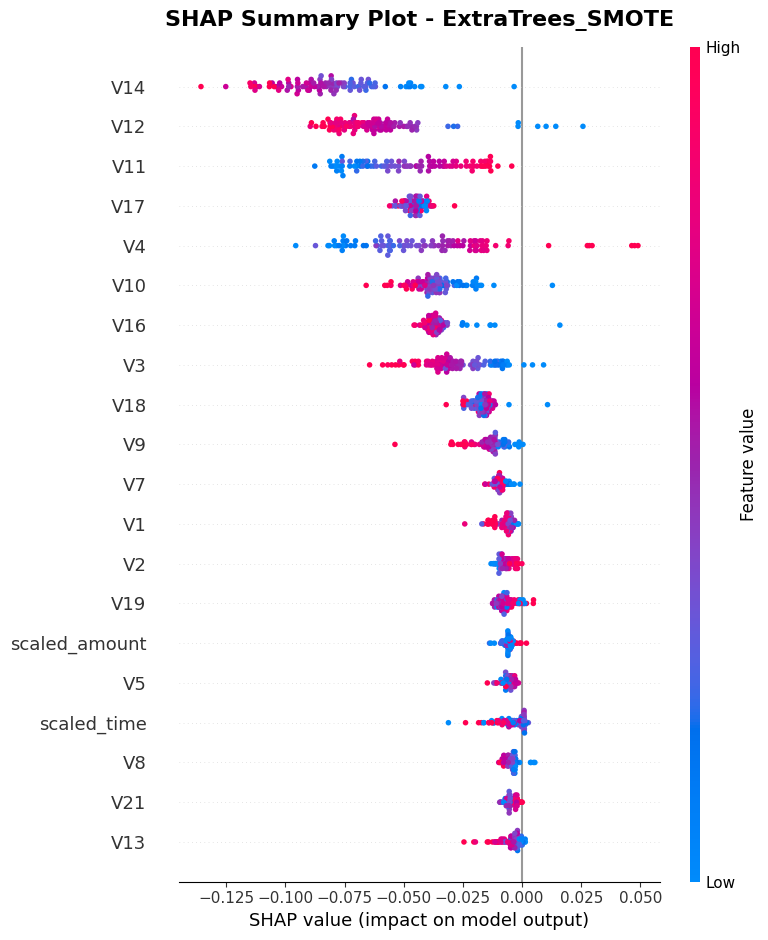

In [15]:
print(f"Vẽ biểu đồ Summary Plot (Beeswarm) cho mô hình: {best_model_name}")

plt.figure(figsize=(10, 6))
plt.title(f"SHAP Summary Plot - {best_model_name}", fontsize=16, fontweight='bold', pad=15)

shap.summary_plot(final_shap_values, X_exai_sample, show=False)

plt.tight_layout()
plt.savefig(f'SHAP_Summary_Plot_{best_model_name}.png', dpi=300)
plt.show()
plt.close()


## 4.4. Biểu đồ Force Plot

Giải thích chi tiết lý do phân loại cho một giao dịch cụ thể, hiện thị đóng góp của từng đặc trưng.


Vẽ biểu đồ Force Plot cho giao dịch mẫu đầu tiên: ExtraTrees_SMOTE


<Figure size 1200x400 with 0 Axes>

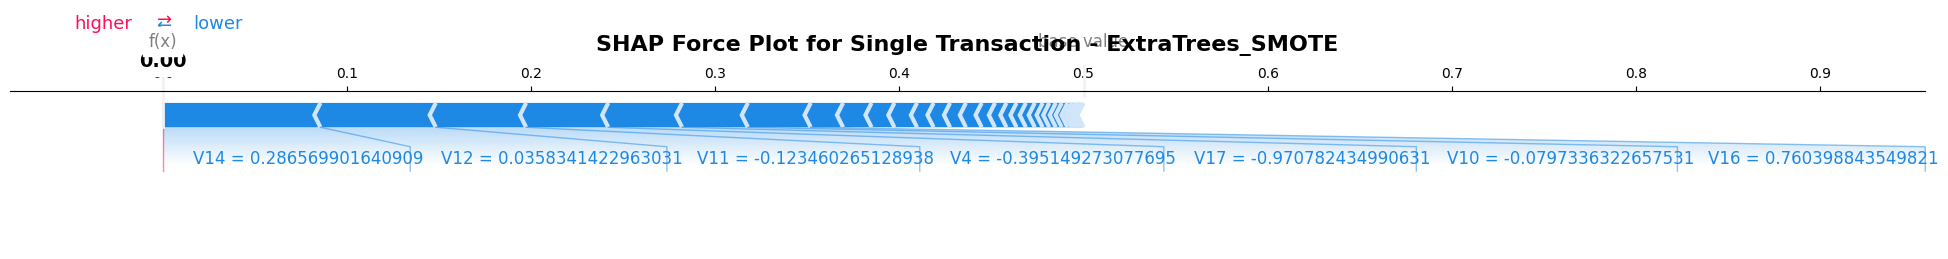

In [16]:
print(f"Vẽ biểu đồ Force Plot cho giao dịch mẫu đầu tiên: {best_model_name}")

if isinstance(shap_values_raw, list) or len(shap_values_raw.shape) == 3:
    expected_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    expected_val = explainer.expected_value

plt.figure(figsize=(12, 4))
shap.force_plot(expected_val, final_shap_values[0], X_exai_sample.iloc[0], matplotlib=True, show=False)

plt.title(f"SHAP Force Plot for Single Transaction - {best_model_name}", fontsize=16, fontweight='bold', y=1.2)

plt.tight_layout()
plt.savefig(f'SHAP_Force_Plot_{best_model_name}.png', dpi=300)
plt.show()
plt.close()


# Giai đoạn 5: Chuẩn bị Web Deploy


Xuất mô hình đã huấn luyện và bộ chuẩn hóa để triển khai trên web application.


In [17]:
import joblib

print("\nCHUẨN BỊ XUẤT MÔ HÌNH CHO WEB DEPLOY")

model_filename = 'fraud_model.pkl'
joblib.dump(best_model_obj, model_filename)
print(f"Đã lưu mô hình tốt nhất ({best_model_name}) thành: {model_filename}")

try:
    scaler_filename = 'scaler.pkl'
    joblib.dump(rob_scaler, scaler_filename) 
    print(f"Đã lưu bộ chuẩn hóa RobustScaler thành: {scaler_filename}")
except NameError:
    print("Không tìm thấy biến rob_scaler trong bộ nhớ.")

print("\nTẤT CẢ ĐÃ SẴN SÀNG ĐỂ DEPLOY!")


CHUẨN BỊ XUẤT MÔ HÌNH CHO WEB DEPLOY
Đã lưu mô hình tốt nhất (ExtraTrees_SMOTE) thành: fraud_model.pkl
Đã lưu bộ chuẩn hóa RobustScaler thành: scaler.pkl

TẤT CẢ ĐÃ SẴN SÀNG ĐỂ DEPLOY!
